# PROJECT GOAL : PREDICTION OF GOOGLE PLAY STORE APP RATING

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Google play store dataset
df = pd.read_csv('googleplaystore.csv')

In [1]:
# Data Understanding

In [3]:
df.shape

(10841, 13)

In [4]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [5]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [7]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [8]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [9]:
df.duplicated().sum()

np.int64(483)

In [10]:
df['Rating'].median()

4.3

<Axes: xlabel='Rating', ylabel='Density'>

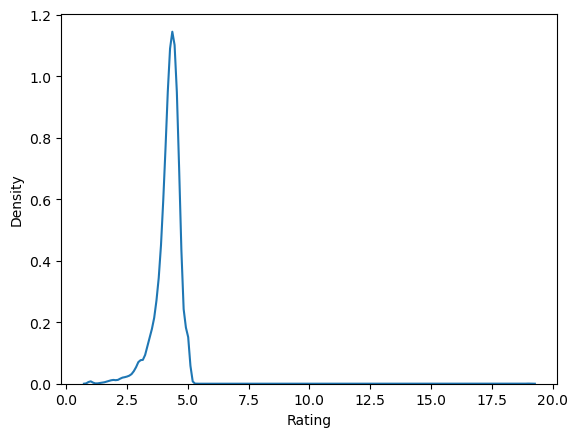

In [11]:
sns.kdeplot(df['Rating'])

In [12]:
df[df['Rating']>5]  # --->>> Invalid Rating

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [13]:
# Median and Mean of rating before removing row no.10472
mean_before = df['Rating'].mean()
median_before = df['Rating'].median()

# Median and Mean of rating after removing row no.10472
new_df = df[df['Rating'] != 19.0]
mean_after = new_df['Rating'].mean()
median_after = new_df['Rating'].median()

In [14]:
print('Before mean ' , mean_before)
print('Before median ' , median_before)
print('After mean ' , mean_after)
print('After median ' , median_after)

Before mean  4.193338315362443
Before median  4.3
After mean  4.191757420456972
After median  4.3


In [15]:
# There is a slight change in mean but median is same.So we can say that we can fill all rating missing values with median of rating values present.

In [16]:
# Decision : As the row no.10472 have uncommon rating value and category value we will remove that corrupted row.

In [17]:
df = df[df['Rating'] != 19.0]
df.shape

(10840, 13)

In [18]:
df['Category'].describe()

count      10840
unique        33
top       FAMILY
freq        1972
Name: Category, dtype: object

In [19]:
df['Type'].describe()

count     10839
unique        2
top        Free
freq      10039
Name: Type, dtype: object

In [20]:
df['Content Rating'].describe()

count        10840
unique           6
top       Everyone
freq          8714
Name: Content Rating, dtype: object

In [21]:
df['Genres'].describe()

count     10840
unique      119
top       Tools
freq        842
Name: Genres, dtype: object

In [22]:
df['Current Ver'].describe()

count                  10832
unique                  2831
top       Varies with device
freq                    1459
Name: Current Ver, dtype: object

In [23]:
df['Android Ver'].describe()

count          10838
unique            33
top       4.1 and up
freq            2451
Name: Android Ver, dtype: object

In [24]:
df.duplicated().sum()   # ---> Complete duplicate rows

np.int64(483)

In [25]:
df['App'].duplicated().sum()   # ---> Duplicate rows in which App is same

np.int64(1181)

In [2]:
# Data cleaning

In [26]:
df = df.drop_duplicates()
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [27]:
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

In [28]:
df = df.dropna()

In [29]:
df.shape

(10346, 13)

In [30]:
df['Rating'].describe()

count    10346.00000
mean         4.20377
std          0.48573
min          1.00000
25%          4.10000
50%          4.30000
75%          4.50000
max          5.00000
Name: Rating, dtype: float64

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df[df['Rating'] <= 5]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,4.3,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [33]:
df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [34]:
# Cleaning Review Column (Convert from object to numeric)
df['Reviews']=df['Reviews'].astype('int64')

C:\Users\TANVI\AppData\Local\Temp\ipykernel_5984\2811819087.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Reviews']=df['Reviews'].astype('int64')


In [35]:
# Cleaning Installs Column (Remove ',','+')
df['Installs']=df['Installs'].astype(str).str.replace('+','')
df['Installs']=df['Installs'].str.replace(',','')
df['Installs']=df['Installs'].astype('float64')

C:\Users\TANVI\AppData\Local\Temp\ipykernel_5984\981270700.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Installs']=df['Installs'].astype(str).str.replace('+','')
C:\Users\TANVI\AppData\Local\Temp\ipykernel_5984\981270700.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Installs']=df['Installs'].str.replace(',','')
C:\Users\TANVI\AppData\Local\Temp\ipykernel_5984\981270700.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

In [36]:
# Cleaning Price column (Remove '$')
df['Price'] = df['Price'].astype(str).str.replace('$','')
df['Price']=df['Price'].astype('float64')

C:\Users\TANVI\AppData\Local\Temp\ipykernel_5984\2684476882.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price'] = df['Price'].astype(str).str.replace('$','')
C:\Users\TANVI\AppData\Local\Temp\ipykernel_5984\2684476882.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price']=df['Price'].astype('float64')


In [37]:
# Cleaning Size column (Convert all Size into same unit)
def convert_size(size):
    if 'M' in str(size):
        return float(size.replace('M',''))*1_000_000
    elif 'k' in str(size):
        return float(size.replace('k',''))*1_000
    else:
        return np.nan
df['Size']=df['Size'].apply(convert_size)       

C:\Users\TANVI\AppData\Local\Temp\ipykernel_5984\3825339233.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Size']=df['Size'].apply(convert_size)


In [38]:
# Cleaning Last Updated column (Convert into raw day/month/year)
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

C:\Users\TANVI\AppData\Local\Temp\ipykernel_5984\3088681939.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Last Updated'] = pd.to_datetime(df['Last Updated'])


In [4]:
# Feature engineering

In [39]:
df['Year Updated'] = df['Last Updated'].dt.year
df['Month Updated'] = df['Last Updated'].dt.month

C:\Users\TANVI\AppData\Local\Temp\ipykernel_5984\2323174342.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year Updated'] = df['Last Updated'].dt.year
C:\Users\TANVI\AppData\Local\Temp\ipykernel_5984\2323174342.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month Updated'] = df['Last Updated'].dt.month


In [40]:
df = df.drop(columns=['Last Updated','App','Genres','Current Ver','Android Ver'])
# REASONS = Last updated --> Not much useful , App --> Useful only as identifier , Genres --> Similar to category column , Current Ver --> Not much useful , Android Ver --> Not much useful

In [41]:
df.isnull().sum()

Category             0
Rating               0
Reviews              0
Size              1525
Installs             0
Type                 0
Price                0
Content Rating       0
Year Updated         0
Month Updated        0
dtype: int64

In [42]:
# Handle missing values in Size column
df['Size Varies'] = df['Size'].isna().astype(int)  # 1 if nan else 0
df['Size'] = df['Size'].replace(np.nan,df['Size'].median())

In [43]:
df.sample()

,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Year Updated,Month Updated,Size Varies
2171,FAMILY,4.4,38,16000000.0,100.0,Paid,0.99,Everyone,2018,6,0


In [44]:
df.shape

(10346, 11)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10346 entries, 0 to 10840
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        10346 non-null  object 
 1   Rating          10346 non-null  float64
 2   Reviews         10346 non-null  int64  
 3   Size            10346 non-null  float64
 4   Installs        10346 non-null  float64
 5   Type            10346 non-null  object 
 6   Price           10346 non-null  float64
 7   Content Rating  10346 non-null  object 
 8   Year Updated    10346 non-null  int32  
 9   Month Updated   10346 non-null  int32  
 10  Size Varies     10346 non-null  int64  
dtypes: float64(4), int32(2), int64(2), object(3)
memory usage: 889.1+ KB


In [46]:
df.duplicated().sum()

np.int64(24)

In [47]:
df.isnull().sum()

Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Year Updated      0
Month Updated     0
Size Varies       0
dtype: int64

In [48]:
df = df.drop_duplicates()

In [49]:
df.shape

(10322, 11)

In [5]:
# EDA

In [50]:
df['Rating'].describe()

count    10322.000000
mean         4.203585
std          0.486250
min          1.000000
25%          4.100000
50%          4.300000
75%          4.500000
max          5.000000
Name: Rating, dtype: float64

<Axes: xlabel='Rating', ylabel='Count'>

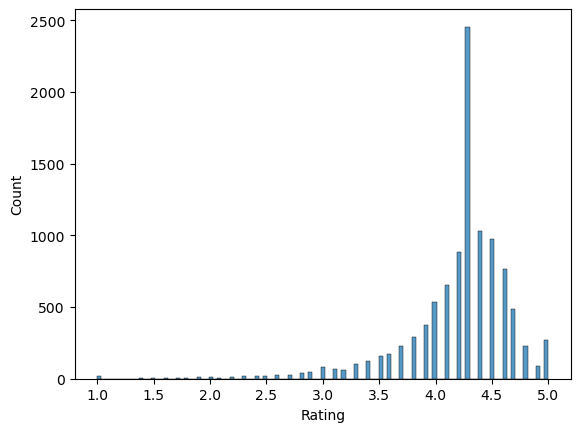

In [51]:
sns.histplot(df['Rating'])

<Axes: ylabel='Rating'>

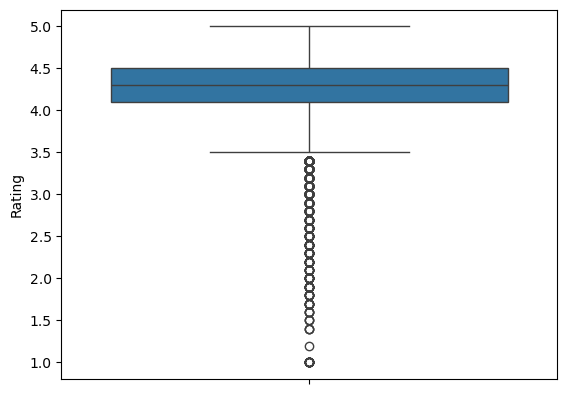

In [52]:
sns.boxplot(df['Rating'])

In [53]:
df['Category'].value_counts()

Category
FAMILY                 1938
GAME                   1121
TOOLS                   838
BUSINESS                426
PRODUCTIVITY            407
MEDICAL                 404
PERSONALIZATION         384
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  340
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     229
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          123
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  81
HOUSE_AND_HOME           80
ART_AND_DESIGN           64
EVENTS                   64
COMICS                   60
PARENTING                60
BEAUTY                   53
Name: count, dtype: int64

In [54]:
df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

Category
EVENTS                 4.395313
EDUCATION              4.375385
ART_AND_DESIGN         4.373437
BOOKS_AND_REFERENCE    4.336681
PERSONALIZATION        4.326563
PARENTING              4.300000
BEAUTY                 4.283019
GAME                   4.282070
HEALTH_AND_FITNESS     4.266993
SOCIAL                 4.260714
SHOPPING               4.256250
WEATHER                4.248148
SPORTS                 4.236471
PRODUCTIVITY           4.219410
MEDICAL                4.213366
LIBRARIES_AND_DEMO     4.208333
AUTO_AND_VEHICLES      4.205882
FAMILY                 4.203664
PHOTOGRAPHY            4.189441
HOUSE_AND_HOME         4.185000
FOOD_AND_DRINK         4.182927
COMMUNICATION          4.175410
BUSINESS               4.174883
NEWS_AND_MAGAZINES     4.160985
COMICS                 4.160000
FINANCE                4.148056
ENTERTAINMENT          4.136036
LIFESTYLE              4.133244
TRAVEL_AND_LOCAL       4.121941
VIDEO_PLAYERS          4.084000
TOOLS                  4.078998

In [55]:
df[['Reviews','Rating']].corr()   # Low correlation

,Reviews,Rating
Reviews,1.000000,0.063536
Rating,0.063536,1.000000


<Axes: >

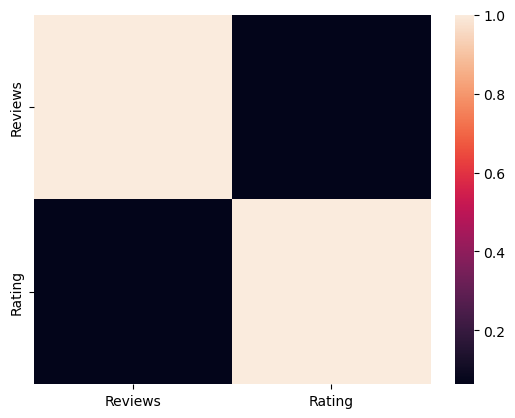

In [56]:
sns.heatmap(df[['Reviews','Rating']].corr())

<Axes: xlabel='Reviews', ylabel='Rating'>

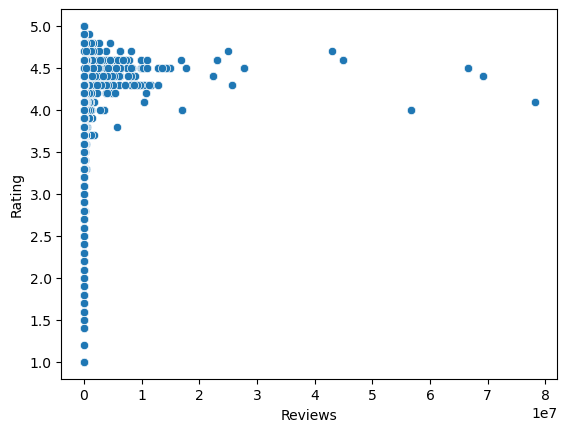

In [57]:
sns.scatterplot(x=df['Reviews'],y=df['Rating'])

In [58]:
df['Reviews'].describe()

count    1.032200e+04
mean     4.072620e+05
std      2.701245e+06
min      0.000000e+00
25%      3.300000e+01
50%      1.720000e+03
75%      4.700225e+04
max      7.815831e+07
Name: Reviews, dtype: float64

In [59]:
df['Reviews'].median()   # Mean >> Median

1720.0

<Axes: xlabel='Reviews', ylabel='Density'>

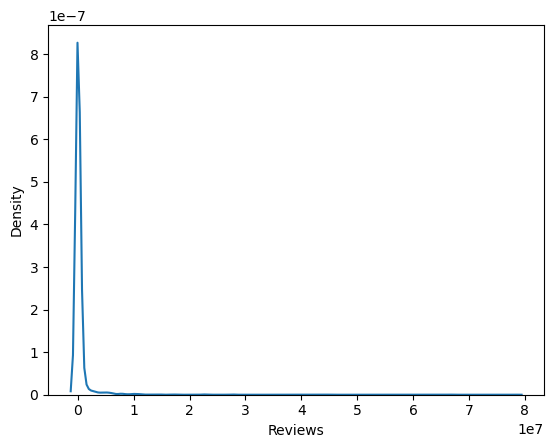

In [60]:
sns.kdeplot(df['Reviews'])

In [88]:
# Before skewness
df['Reviews'].skew()

np.float64(0.020335363324211656)

In [89]:
df['Reviews'] = np.log1p(df['Reviews'])

In [90]:
# After skewness
df['Reviews'].skew()

np.float64(-1.078513842006823)

In [62]:
df['Reviews'].describe()

count    10322.000000
mean         7.267498
std          4.361676
min          0.000000
25%          3.526361
50%          7.450661
75%         10.757971
max         18.174247
Name: Reviews, dtype: float64

In [63]:
df['Reviews'].median()

7.450660627397587

<Axes: xlabel='Reviews', ylabel='Density'>

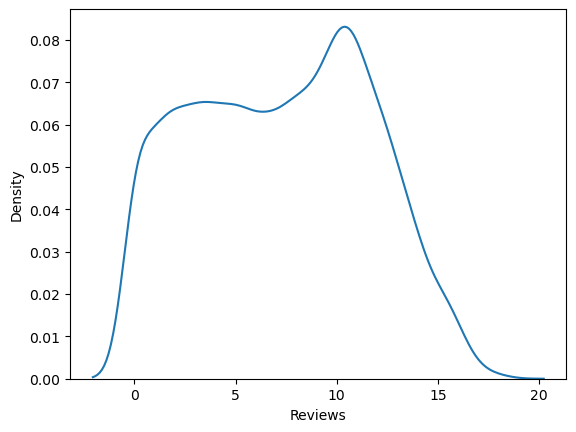

In [64]:
sns.kdeplot(df['Reviews'])

In [92]:
# Before Skewness
df['Installs'].skew()

np.float64(-0.2745209253394325)

In [93]:
df['Installs'] = np.log1p(df['Installs'])

In [94]:
# After Skewness
df['Installs'].skew()

np.float64(-1.3386595225512825)

In [66]:
df[['Installs','Rating']].corr()

,Installs,Rating
Installs,1.00000,0.04365
Rating,0.04365,1.00000


<Axes: xlabel='Installs', ylabel='Rating'>

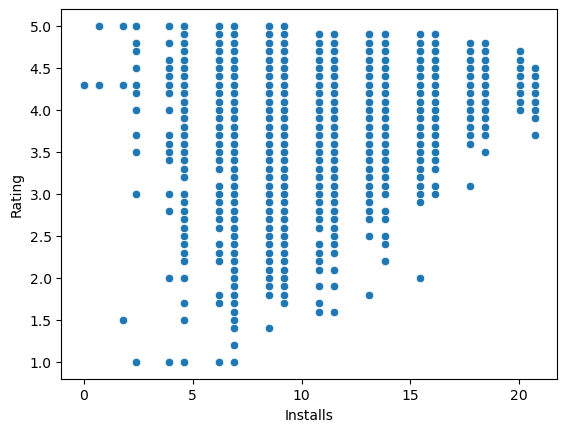

In [67]:
sns.scatterplot(x=df['Installs'],y=df['Rating'])

In [68]:
df.groupby('Type')['Rating'].agg(['count','mean','median'])

,count,mean,median
Type,,,
Free,9560,4.198347,4.3
Paid,762,4.269291,4.3


In [69]:
df.groupby('Content Rating')['Rating'].agg(['count','mean','median'])

,count,mean,median
Content Rating,,,
Adults only 18+,3,4.300000,4.5
Everyone,8350,4.198946,4.3
Everyone 10+,376,4.256117,4.3
Mature 17+,447,4.138479,4.2
Teen,1144,4.245367,4.3
Unrated,2,4.200000,4.2


In [70]:
df[['Price','Rating']].corr()

,Price,Rating
Price,1.000000,-0.019698
Rating,-0.019698,1.000000


<Axes: xlabel='Price', ylabel='Rating'>

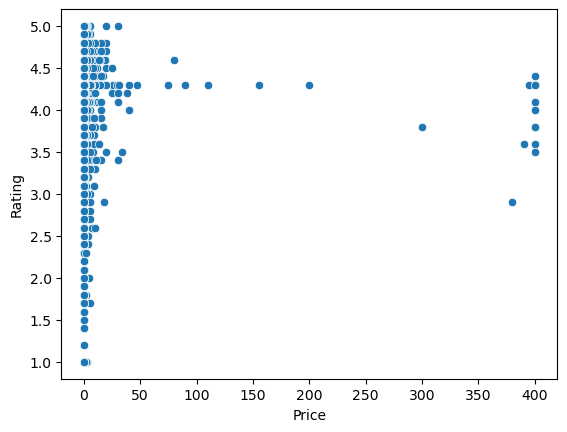

In [71]:
sns.scatterplot(x=df['Price'],y=df['Rating'])

<Axes: xlabel='Price', ylabel='Density'>

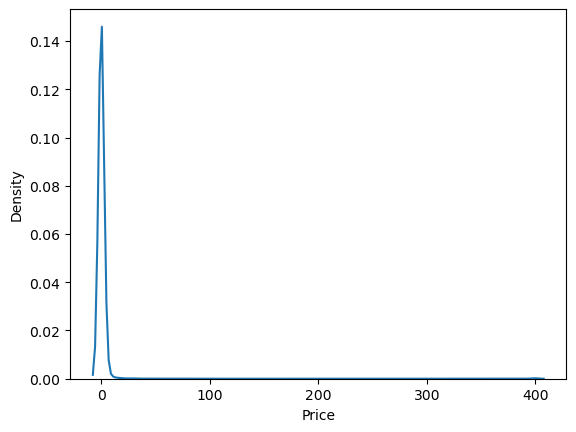

In [72]:
sns.kdeplot(df['Price'])

In [74]:
df.groupby('Year Updated')['Rating'].agg(['count','mean','median'])

,count,mean,median
Year Updated,,,
2010,1,4.200000,4.2
2011,15,3.966667,4.0
2012,26,3.884615,4.2
2013,107,4.103738,4.2
2014,204,4.061275,4.2
2015,454,4.101322,4.2
2016,786,4.088422,4.3
2017,1821,4.135146,4.3
2018,6908,4.248914,4.3


In [95]:
# Before Skewness
df['Size'].skew()

np.float64(-0.931623236902713)

In [76]:
df['Size'] = np.log1p(df['Size'])

In [96]:
# After Skewness
df['Size'].skew()

np.float64(-0.931623236902713)

<Axes: xlabel='Size', ylabel='Rating'>

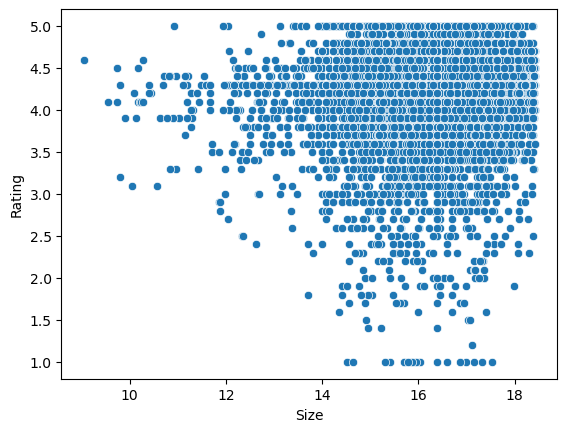

In [77]:
sns.scatterplot(x=df['Size'],y=df['Rating'])

<Axes: xlabel='Size Varies', ylabel='Rating'>

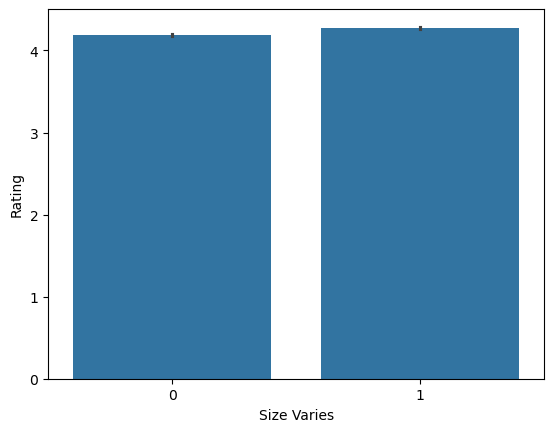

In [80]:
sns.barplot(x=df['Size Varies'],y=df['Rating'])

<Axes: xlabel='Size Varies', ylabel='Rating'>

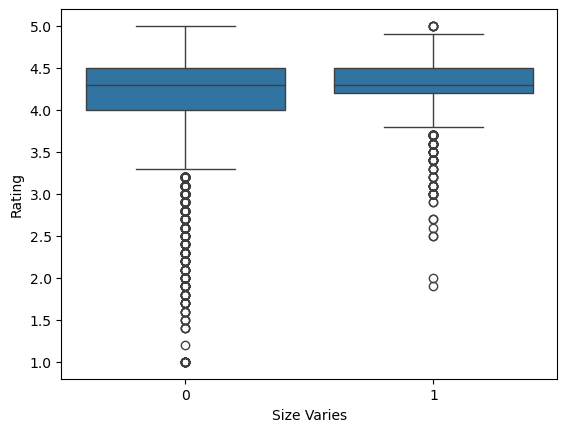

In [81]:
sns.boxplot(x=df['Size Varies'],y=df['Rating'])

In [82]:
df.groupby('Month Updated')['Rating'].agg(['count','mean','median'])

,count,mean,median
Month Updated,,,
1,477,4.170021,4.30
2,515,4.133981,4.30
3,655,4.144275,4.30
4,593,4.180101,4.30
5,961,4.178460,4.30
6,1224,4.196487,4.30
7,2947,4.254801,4.30
8,1464,4.290915,4.30
9,308,4.088961,4.25


In [97]:
df[['Reviews','Installs','Price','Size']].describe()

,Reviews,Installs,Price,Size
count,10322.000000,10322.000000,10322.000000,10322.000000
mean,1.904033,2.401254,1.033960,16.256535
std,0.736587,0.478005,16.306102,1.202358
min,0.000000,0.000000,0.000000,9.047939
25%,1.509918,2.067970,0.000000,15.555977
50%,2.134245,2.526763,0.000000,16.380460
75%,2.464531,2.695675,0.000000,17.073607
max,2.953568,3.078384,400.000000,18.420681


In [98]:
# Before skewness
df['Price'].skew()

np.float64(23.28480442468659)

In [100]:
df['Price'] = np.log1p(df['Price'])

In [101]:
# After skewness
df['Price'].skew()

np.float64(5.992788290044696)

In [102]:
df[['Rating','Reviews','Size','Installs','Price','Year Updated','Month Updated','Size Varies']].corr()

,Rating,Reviews,Size,Installs,Price,Year Updated,Month Updated,Size Varies
Rating,1.000000,0.048653,0.070492,-0.006041,0.017352,0.123367,0.013557,0.059202
Reviews,0.048653,1.000000,0.259958,0.935040,-0.117804,0.144989,0.078471,0.282358
Size,0.070492,0.259958,1.000000,0.248942,-0.070180,0.381333,0.040391,0.055582
Installs,-0.006041,0.935040,0.248942,1.000000,-0.205649,0.149828,0.070584,0.286714
Price,0.017352,-0.117804,-0.070180,-0.205649,1.000000,-0.128846,-0.000082,-0.035827
Year Updated,0.123367,0.144989,0.381333,0.149828,-0.128846,1.000000,-0.190108,0.147631
Month Updated,0.013557,0.078471,0.040391,0.070584,-0.000082,-0.190108,1.000000,0.055102
Size Varies,0.059202,0.282358,0.055582,0.286714,-0.035827,0.147631,0.055102,1.000000


In [108]:
df.sample(5)

,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Year Updated,Month Updated,Size Varies
3947,FAMILY,3.9,2.428666,2.956698,2.695675,Free,0.0,Everyone,2018,6,0
9840,FINANCE,4.2,2.408136,2.855347,2.695675,Free,0.0,Everyone,2018,7,1
644,DATING,4.3,0.000000,2.797571,1.223156,Free,0.0,Teen,2018,7,0
4604,PRODUCTIVITY,4.1,1.933867,2.900476,2.647760,Free,0.0,Everyone,2018,1,0
9021,HEALTH_AND_FITNESS,4.3,0.000000,2.918008,1.223156,Free,0.0,Everyone,2016,4,0


In [103]:
X = df.drop(columns='Rating')
y = df['Rating']

In [6]:
# ML model training

In [104]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [105]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((8257, 10), (2065, 10), (8257,), (2065,))

In [109]:
# Categorical Features : Category,Type,Content Rating
# Numerical Features : Reviews,Size,Installs,Price,Year Updated,Month Updated,Size Varies

In [116]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [122]:
transformer = ColumnTransformer(transformers=[('tnf1',OneHotEncoder(handle_unknown='ignore'),['Category','Type','Content Rating']),('tnf2',StandardScaler(),['Reviews','Size','Installs','Price','Year Updated','Month Updated','Size Varies'])])

In [123]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [124]:
pipe = Pipeline([('transformer', transformer),('lr', LinearRegression())])

In [126]:
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformer', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Category','Reviews','Size',...,'Year Updated','Month Updated', 'Size Varies']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tnf1', ...), ('tnf2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

In [129]:
y_pred = pipe.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.03690378568129826

In [130]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.03690378568129826
MAE: 0.3208788512401753
RMSE: 0.4682621218288285


In [131]:
# Linear Regression doesn't perform well because features are not in linear relation with target.

In [134]:
from sklearn.ensemble import RandomForestRegressor

In [135]:
pipe = Pipeline([('transformer', transformer),('rf', RandomForestRegressor(random_state=42))])

In [136]:
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformer', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Category','Reviews','Size',...,'Year Updated','Month Updated', 'Size Varies']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tnf1', ...), ('tnf2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

In [137]:
y_pred = pipe.predict(X_test)
r2_score(y_test,y_pred)

0.08762118443183631

In [138]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.08762118443183631
MAE: 0.2907118851608439
RMSE: 0.45576585669266345


In [139]:
y_pred_train = pipe.predict(X_train)
r2_score(y_train, y_pred_train)

0.8783953552196466

In [140]:
print('R2 Score of Train data ' , r2_score(y_train, y_pred_train))
print('R2 Score of Test data ' , r2_score(y_test, y_pred))

R2 Score of Train data  0.8783953552196466
R2 Score of Test data  0.08762118443183631


In [143]:
# Clearly overfitting
# On test data random forest perform better than liner regression so we will do hyperparameter tuning.

In [153]:
feature_names = pipe.named_steps['transformer'].get_feature_names_out()

importances = pipe.named_steps['rf'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
41,tnf2__Reviews,0.267991
42,tnf2__Size,0.198383
46,tnf2__Month Updated,0.111125
43,tnf2__Installs,0.099602
45,tnf2__Year Updated,0.049409
44,tnf2__Price,0.018777
11,tnf1__Category_FAMILY,0.017181
29,tnf1__Category_TOOLS,0.013800
18,tnf1__Category_LIFESTYLE,0.013078
15,tnf1__Category_HEALTH_AND_FITNESS,0.012881


In [157]:
pipe = Pipeline([('transformer', transformer),('rf', RandomForestRegressor(n_estimators=300,max_depth=8,min_samples_split=20,min_samples_leaf=10,random_state=42))])

In [160]:
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformer', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Category','Reviews','Size',...,'Year Updated','Month Updated', 'Size Varies']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tnf1', ...), ('tnf2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

In [161]:
y_pred = pipe.predict(X_test)
y_pred_train = pipe.predict(X_train)

In [162]:
print('R2 Score of Train data ' , r2_score(y_train, y_pred_train))
print('R2 Score of Test data ' , r2_score(y_test, y_pred))

R2 Score of Train data  0.22043644774620708
R2 Score of Test data  0.12388973293669248
